In [50]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV  # this is a new method
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report




In [51]:
df = pd.read_csv('train.csv')
df.info()

test_df = pd.read_csv('test.csv')

df['AQ_sum'] = df[[f'A{i}_Score' for i in range(1,11)]].sum(axis=1)
df[['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score',
    'A6_Score','A7_Score','A8_Score','A9_Score','A10_Score','AQ_sum']].head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,AQ_sum
0,1,0,1,1,1,1,0,1,1,1,8
1,0,0,0,0,0,0,0,0,0,1,1
2,1,1,1,1,1,1,0,0,1,1,8
3,0,0,0,1,0,0,0,0,0,0,1
4,0,0,0,0,1,0,0,0,1,1,3


In [52]:
print("First few rows of the dataset:")
display(df.head(10))

First few rows of the dataset:


,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD,AQ_sum
0,1,1,0,1,1,1,1,0,1,1,...,White-European,no,no,United States,no,7.819715,18 and more,Self,0,8
1,2,0,0,0,0,0,0,0,0,0,...,South Asian,no,no,Australia,no,10.544296,18 and more,?,0,1
2,3,1,1,1,1,1,1,0,0,1,...,White-European,no,no,United Kingdom,no,13.167506,18 and more,Self,1,8
3,4,0,0,0,1,0,0,0,0,0,...,South Asian,no,no,New Zealand,no,1.530098,18 and more,?,0,1
4,5,0,0,0,0,1,0,0,0,1,...,Black,no,yes,Italy,no,7.949723,18 and more,Self,0,3
5,6,1,0,0,0,0,0,0,1,0,...,Asian,no,no,Nicaragua,no,7.445003,18 and more,?,0,2
6,7,1,1,1,1,1,1,0,1,0,...,White-European,no,no,Canada,no,12.598583,18 and more,Self,0,7
7,8,0,0,0,0,0,0,0,0,0,...,Middle Eastern,yes,no,United Arab Emirates,no,3.525720,18 and more,?,0,0
8,9,1,1,1,1,1,1,1,1,1,...,White-European,yes,no,United Kingdom,no,11.902461,18 and more,Self,1,9
9,10,0,0,0,0,0,0,1,1,0,...,?,yes,no,United States,no,8.633346,18 and more,Self,1,3


In [25]:
df.isnull().values.any()

False

In [26]:
#check for unique values
for column in df.columns:
    unique_values = df[column].unique()
    print(f"\nUnique values in '{column}':/n{unique_values}")



Unique values in 'ID':/n[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 2

In [37]:

# drop ID and other unhelpful columns
df = df.copy()
if 'ID' in df.columns:
    df.drop(columns=['ID'], inplace=True)
#drop result
if 'result' in df.columns:
    df.drop(columns=['result'], inplace=True)
#drop country of origin
if 'contry_of_res' in df.columns:
    df.drop(columns=['contry_of_res'], inplace=True)
#drop ethnicity
if 'ethnicity' in df.columns:
    df.drop(columns=['ethnicity'], inplace=True)


# If 'Class/ASD' is already integer 0/1, keep it
y = df['Class/ASD'].astype(int)
X = df.drop(columns=['Class/ASD'])

# Convert obvious numeric columns
numeric_cols = ['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score','A6_Score',
                'A7_Score','A8_Score','A9_Score','A10_Score','age']
# Ensure types
for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors='coerce')

# For categorical columns use get_dummies; drop columns that are IDs, question marks, or not helpful
cat_cols = [c for c in X.columns if c not in numeric_cols]
X_cat = pd.get_dummies(X[cat_cols].fillna('Missing'), drop_first=True)

# Combine
X_proc = pd.concat([X[numeric_cols].reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
print("Final feature matrix shape:", X_proc.shape)


Final feature matrix shape: (800, 21)


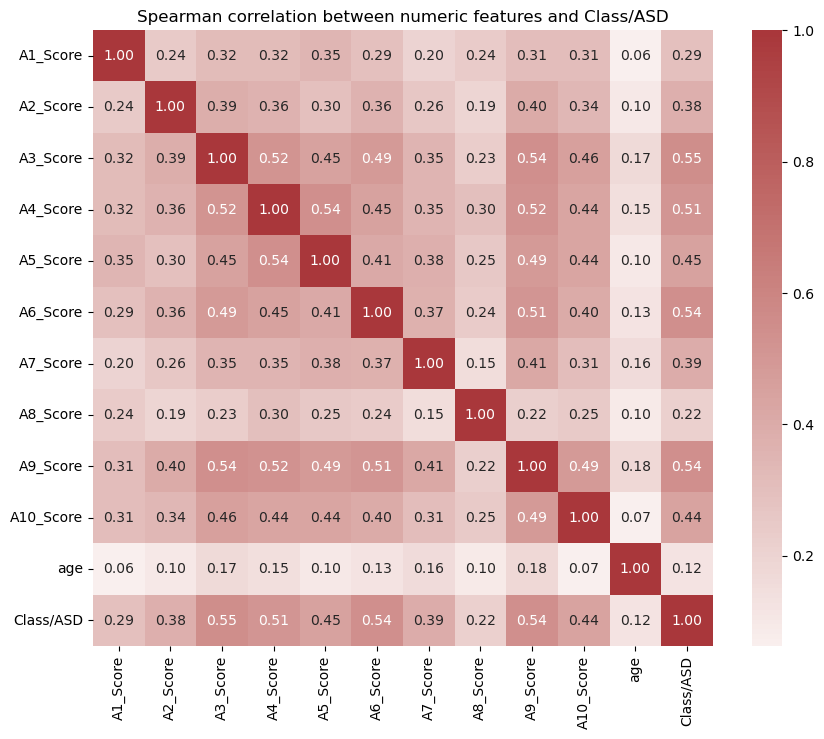

In [38]:
# correlation heatmap (Spearman or Pearson)
corr = pd.concat([X_proc[numeric_cols], y.rename('Class/ASD')], axis=1).corr(method='spearman')
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title("Spearman correlation between numeric features and Class/ASD")
plt.show()

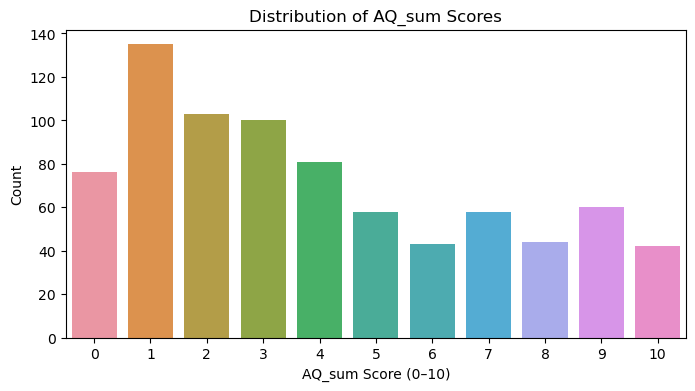

In [35]:
#This would be a graph of how many people scored on each of the tests. If they tested positive on one test, 
# that adds one to thier AQ_Sum Score
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='AQ_sum')
plt.title('Distribution of AQ_sum Scores')
plt.xlabel('AQ_sum Score (0–10)')
plt.ylabel('Count')
plt.show()



Predictions for test.csv saved to test_predictions.csv


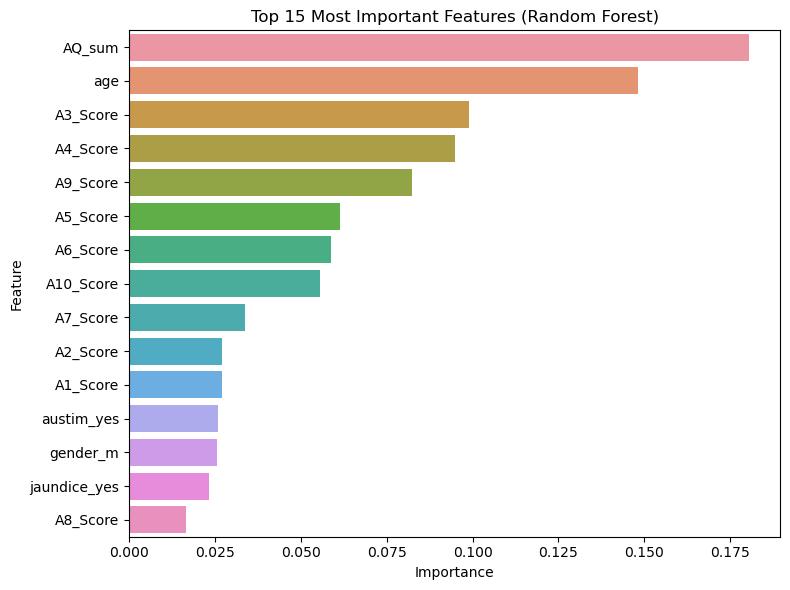


Top Predictors by Permutation Importance:

         feature  importance_mean  importance_std
11        AQ_sum          0.13150        0.016055
3       A4_Score          0.04375        0.009984
2       A3_Score          0.04325        0.009523
1       A2_Score          0.03375        0.009066
4       A5_Score          0.03350        0.005937
6       A7_Score          0.02850        0.011303
10           age          0.02750        0.009421
5       A6_Score          0.02625        0.007049
8       A9_Score          0.02600        0.007348
0       A1_Score          0.02025        0.006978
9      A10_Score          0.01775        0.006978
12      gender_m          0.01775        0.005585
13  jaundice_yes          0.01400        0.005385
7       A8_Score          0.00875        0.004969
14    austim_yes          0.00700        0.003317


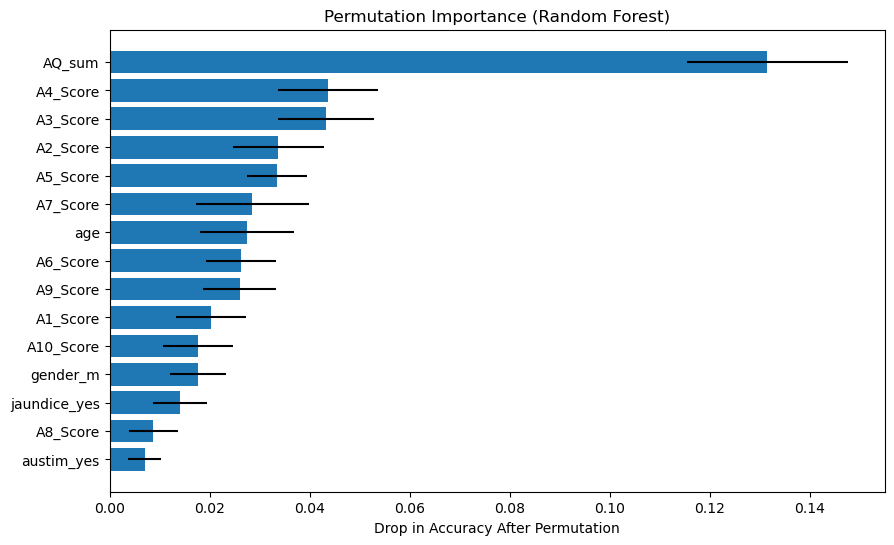

In [53]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------
# 1. LOAD TRAIN & TEST DATA
# -----------------------------------------------
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# -----------------------------------------------
# 2. DROP UNWANTED COLUMNS IN BOTH DATASETS
# -----------------------------------------------
cols_to_drop = ['result', 'contry_of_res', 'ethnicity', 'ID']

train_df = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns])
test_df = test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns])

# -----------------------------------------------
# 3. CREATE AQ_sum IN BOTH DATASETS
# -----------------------------------------------
aq_items = [f"A{i}_Score" for i in range(1, 11)]

train_df["AQ_sum"] = train_df[aq_items].sum(axis=1)
test_df["AQ_sum"] = test_df[aq_items].sum(axis=1)

# -----------------------------------------------
# 4. SPLIT TRAIN INTO X AND y
# -----------------------------------------------
X_train = train_df.drop("Class/ASD", axis=1)
y_train = train_df["Class/ASD"]

# -----------------------------------------------
# 5. ONE-HOT ENCODE TRAIN & TEST THE SAME WAY
# -----------------------------------------------
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(test_df, drop_first=True)

# Make sure test columns match train columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# -----------------------------------------------
# 6. TRAIN RANDOM FOREST
# -----------------------------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

# -----------------------------------------------
# 7. PREDICT ON EXTERNAL test.csv
# -----------------------------------------------
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# Save predictions (optional)
pred_output = pd.DataFrame({
    "Prediction": y_pred,
    "Probability_ASD": y_prob
})
pred_output.to_csv("test_predictions.csv", index=False)

print("\nPredictions for test.csv saved to test_predictions.csv")

# -----------------------------------------------
# 8. FEATURE IMPORTANCE (Random Forest)
# -----------------------------------------------
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 15 Most Important Features (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# -----------------------------------------------
# 9. PERMUTATION IMPORTANCE (on test.csv)
# -----------------------------------------------
perm = permutation_importance(
    rf,
    X_test,
    y_pred,     # there is no y_test, so permutation is vs predicted labels
    n_repeats=20,
    random_state=42,
    scoring='accuracy'
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nTop Predictors by Permutation Importance:\n")
print(perm_df.head(15))

top = perm_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top['feature'], top['importance_mean'], xerr=top['importance_std'])
plt.xlabel("Drop in Accuracy After Permutation")
plt.title("Permutation Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


Validation Accuracy: 0.86875

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.92       123
           1       0.75      0.65      0.70        37

    accuracy                           0.87       160
   macro avg       0.82      0.79      0.81       160
weighted avg       0.86      0.87      0.87       160



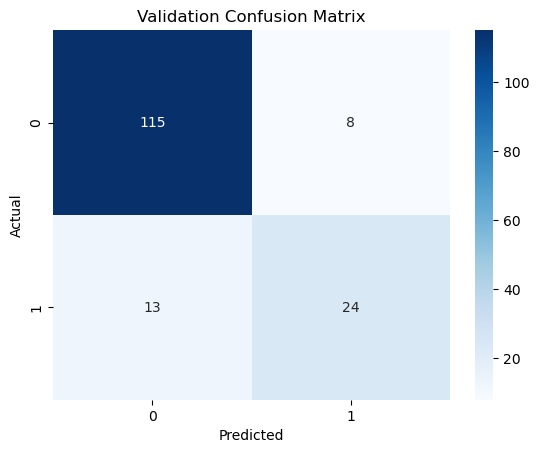

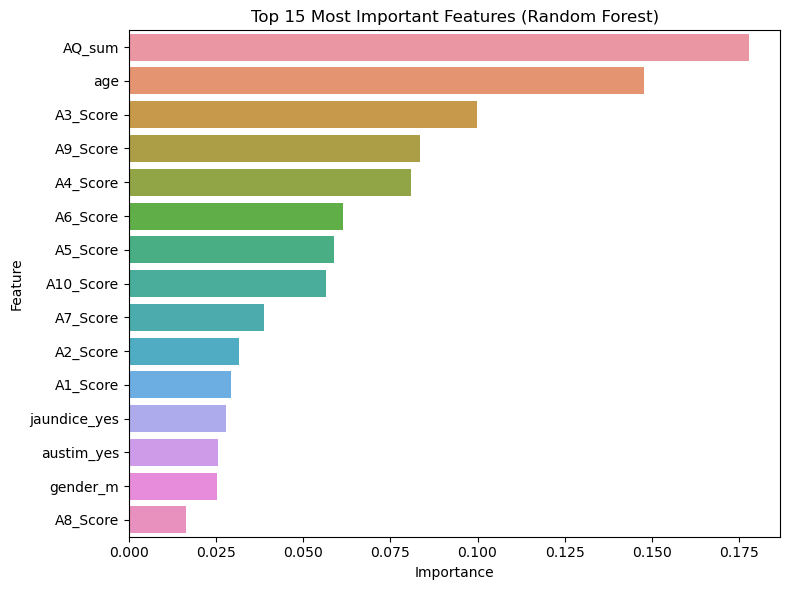


Top Predictors by Permutation Importance:

            feature  importance_mean  importance_std
11           AQ_sum         0.054688        0.018422
14       austim_yes         0.022500        0.005728
10              age         0.015313        0.008262
12         gender_m         0.010938        0.009030
7          A8_Score         0.010313        0.005331
3          A4_Score         0.008438        0.006335
1          A2_Score         0.008438        0.005685
9         A10_Score         0.007813        0.006518
13     jaundice_yes         0.007500        0.007289
5          A6_Score         0.006563        0.011088
18  relation_Parent         0.006250        0.002795
20    relation_Self         0.005625        0.005192
2          A3_Score         0.005313        0.006335
0          A1_Score         0.004688        0.007623
8          A9_Score         0.004063        0.006925


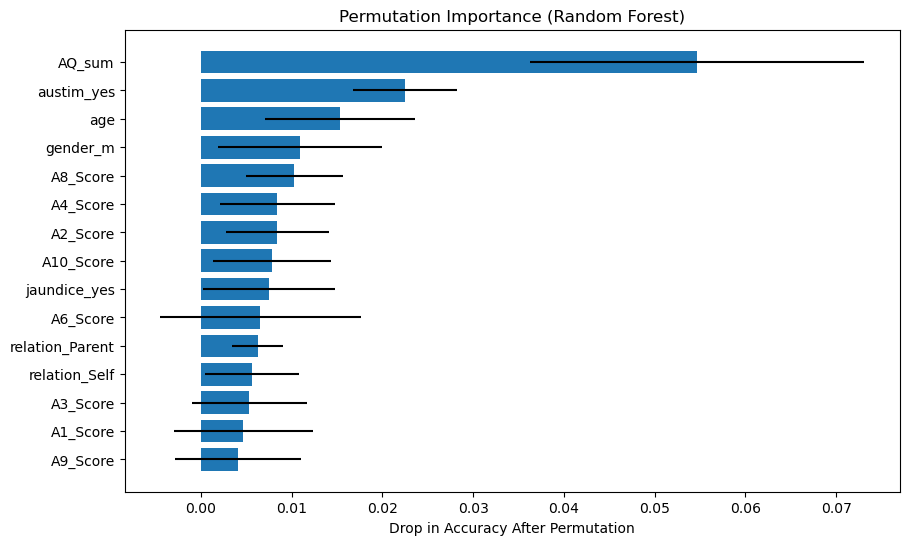

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------
# 1. LOAD TRAINING DATA
# -----------------------------------------------
train = pd.read_csv("train.csv")

# -----------------------------------------------
# 2. DROP UNWANTED COLUMNS
# -----------------------------------------------
cols_to_drop = ['result', 'contry_of_res', 'ethnicity', 'ID']
train = train.drop(columns=[c for c in cols_to_drop if c in train.columns])

# -----------------------------------------------
# 3. CREATE AQ_sum
# -----------------------------------------------
aq_items = [f"A{i}_Score" for i in range(1, 11)]
train["AQ_sum"] = train[aq_items].sum(axis=1)

# -----------------------------------------------
# 4. SPLIT INTO TRAIN/VALIDATION
# -----------------------------------------------
X = train.drop("Class/ASD", axis=1)
y = train["Class/ASD"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------------------------
# 5. ENCODE
# -----------------------------------------------
X_train = pd.get_dummies(X_train, drop_first=True)
X_val   = pd.get_dummies(X_val, drop_first=True)

# Align validation columns to training columns
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

# -----------------------------------------------
# 6. TRAIN RANDOM FOREST
# -----------------------------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)

# -----------------------------------------------
# 7. PREDICT ON VALIDATION SET
# -----------------------------------------------
y_val_pred = rf.predict(X_val)
y_val_prob = rf.predict_proba(X_val)[:, 1]

# -----------------------------------------------
# 8. EVALUATE ACCURACY
# -----------------------------------------------
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------------------------
# 9. FEATURE IMPORTANCE
# -----------------------------------------------
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 15 Most Important Features (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# -----------------------------------------------
# 10. PERMUTATION IMPORTANCE ON VALIDATION SET
# -----------------------------------------------
perm = permutation_importance(
    rf,
    X_val,
    y_val,
    n_repeats=20,
    random_state=42,
    scoring='accuracy'
)

perm_df = pd.DataFrame({
    'feature': X_val.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nTop Predictors by Permutation Importance:\n")
print(perm_df.head(15))

# Plot permutation importance
top = perm_df.head(15)
plt.figure(figsize=(10,6))
plt.barh(top['feature'], top['importance_mean'], xerr=top['importance_std'])
plt.xlabel("Drop in Accuracy After Permutation")
plt.title("Permutation Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()



In [ ]:
# Question #2 is going to be is the A1_Score through A10_Score is
#more predictive than the other variables. I'm going to take out 
# the rest of the variables in the table and only use the A1_Score 
# through A10_Score and then predict

Validation Accuracy: 0.85625

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91       123
           1       0.71      0.65      0.68        37

    accuracy                           0.86       160
   macro avg       0.80      0.78      0.79       160
weighted avg       0.85      0.86      0.85       160



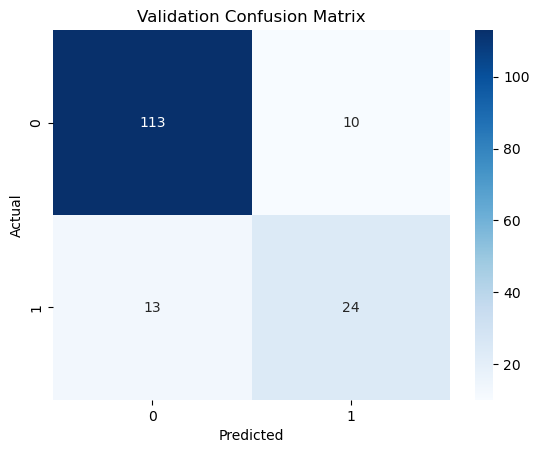

In [59]:
cols_to_drop = ['autism_yes', 'age', 'gender_m', 'jaundice_yes', 'relation_Parent', 'relation_Self']
train = train.drop(columns=[c for c in cols_to_drop if c in train.columns])

# -----------------------------------------------
# 3. CREATE AQ_sum
# -----------------------------------------------
aq_items = [f"A{i}_Score" for i in range(1, 11)]
train["AQ_sum"] = train[aq_items].sum(axis=1)

# -----------------------------------------------
# 4. SPLIT INTO TRAIN/VALIDATION
# -----------------------------------------------
X = train.drop("Class/ASD", axis=1)
y = train["Class/ASD"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------------------------
# 5. ENCODE
# -----------------------------------------------
X_train = pd.get_dummies(X_train, drop_first=True)
X_val   = pd.get_dummies(X_val, drop_first=True)

# Align validation columns to training columns
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

# -----------------------------------------------
# 6. TRAIN RANDOM FOREST
# -----------------------------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)

# -----------------------------------------------
# 7. PREDICT ON VALIDATION SET
# -----------------------------------------------
y_val_pred = rf.predict(X_val)
y_val_prob = rf.predict_proba(X_val)[:, 1]

# -----------------------------------------------
# 8. EVALUATE ACCURACY
# -----------------------------------------------
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



In [ ]:
#Question #3 is going to be about if early in life or demographic 
# factors influence the likelihood of testing positive for ASD. 
# I'm not sure how to do this exactly 
# drop age variable and recode using over 18 and under 18 variable 
# or use decision tree to find age cutoff. asking if the questionairre 
# preforms differently. split it into over and uder 18 or cluster would 
# i get a different model

Validation Accuracy: 0.84375

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90       123
           1       0.69      0.59      0.64        37

    accuracy                           0.84       160
   macro avg       0.79      0.76      0.77       160
weighted avg       0.84      0.84      0.84       160



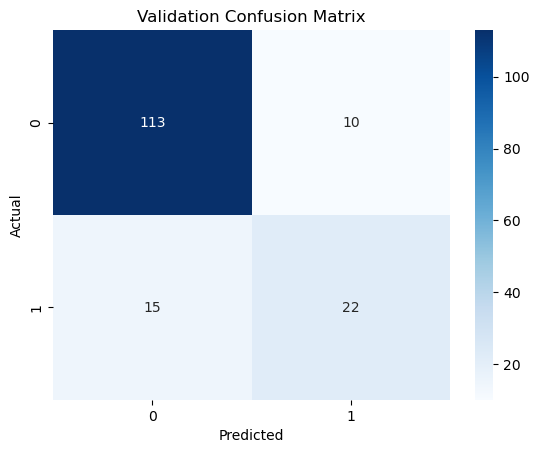

In [63]:
train = pd.read_csv("train.csv")

# -----------------------------------------------
# 2. DROP UNWANTED COLUMNS
# -----------------------------------------------
cols_to_drop = ['result', 'contry_of_res', 'ethnicity', 'ID']
train = train.drop(columns=[c for c in cols_to_drop if c in train.columns])

train["over18"] = (train["age"] >= 18).astype(int)
train = train.drop("age", axis=1)

# -----------------------------------------------
# 4. SPLIT INTO TRAIN/VALIDATION
# -----------------------------------------------
X = train.drop("Class/ASD", axis=1)
y = train["Class/ASD"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------------------------
# 5. ENCODE
# -----------------------------------------------
X_train = pd.get_dummies(X_train, drop_first=True)
X_val   = pd.get_dummies(X_val, drop_first=True)

# Align validation columns to training columns
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

# -----------------------------------------------
# 6. TRAIN RANDOM FOREST
# -----------------------------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)

# -----------------------------------------------
# 7. PREDICT ON VALIDATION SET
# -----------------------------------------------
y_val_pred = rf.predict(X_val)
y_val_prob = rf.predict_proba(X_val)[:, 1]

# -----------------------------------------------
# 8. EVALUATE ACCURACY
# -----------------------------------------------
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [64]:
#permutation for how predictive over18 is
from sklearn.inspection import permutation_importance

# Permutation importance on validation set
perm = permutation_importance(
    rf,
    X_val,
    y_val,
    n_repeats=20,
    random_state=42,
    scoring='accuracy'
)

perm_df = pd.DataFrame({
    'feature': X_val.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nTop Predictors by Permutation Importance:\n")
print(perm_df.head(15))

# Check specifically for over18 importance
if 'over18' in perm_df.feature.values:
    print("\nPermutation importance for over18:")
    print(perm_df[perm_df.feature == 'over18'])
else:
    print("\n'over18' was not included as a feature after encoding.")



Top Predictors by Permutation Importance:

                              feature  importance_mean  importance_std
3                            A4_Score         0.016562        0.011571
5                            A6_Score         0.011563        0.013874
4                            A5_Score         0.005000        0.012279
10                             over18         0.004687        0.006518
6                            A7_Score         0.003437        0.007775
2                            A3_Score         0.001563        0.007875
15  relation_Health care professional         0.000625        0.001875
14                used_app_before_yes         0.000000        0.000000
16                    relation_Others         0.000000        0.000000
18                  relation_Relative        -0.000937        0.004086
1                            A2_Score        -0.001562        0.009244
17                    relation_Parent        -0.006562        0.002400
9                           A10_S

In [65]:
# Compare ASD rates by age group
over18_rates = train[train["over18"] == 1]["Class/ASD"].value_counts(normalize=True)
under18_rates = train[train["over18"] == 0]["Class/ASD"].value_counts(normalize=True)

print("\nASD Rates for OVER 18:")
print(over18_rates)

print("\nASD Rates for UNDER 18:")
print(under18_rates)



ASD Rates for OVER 18:
0    0.758887
1    0.241113
Name: Class/ASD, dtype: float64

ASD Rates for UNDER 18:
0    0.810458
1    0.189542
Name: Class/ASD, dtype: float64


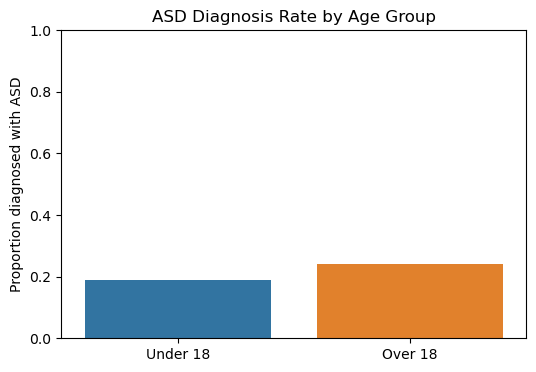

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(
    x=["Under 18", "Over 18"],
    y=[under18_rates.get(1, 0), over18_rates.get(1, 0)]
)
plt.ylabel("Proportion diagnosed with ASD")
plt.title("ASD Diagnosis Rate by Age Group")
plt.ylim(0,1)
plt.show()
